# IF5171 Deep Learning for Visual Recognition -- Week 7
___
Name: Arief Purnama Muharram<br>
NIM: 23521013

## Step 0: Prerequisties
___

### 0.1: Mount Google Drive

In [ ]:
from google.colab import drive 


drive.mount('/content/drive/')

Mounted at /content/drive/


### 0.2: Install required packages

In [ ]:
!pip install pandas
!pip install tqdm
!pip install pillow
!pip install seaborn
!pip install scikit-learn
!pip install torch
!pip isntall torchvision

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: unknown command "isntall" - maybe you meant "install"


In [ ]:
import pandas
import tqdm
import PIL
import seaborn
import sklearn
import torch
import torchvision


print('Pandas version:', pandas.__version__)
print('PIL version:', PIL.__version__)
print('Tqdm version:', tqdm.__version__)
print('Seaborn version:', seaborn.__version__)
print('Scikit-learn version:', sklearn.__version__)
print('Torch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

Pandas version: 1.3.5
PIL version: 7.1.2
Tqdm version: 4.64.1
Seaborn version: 0.11.2
Scikit-learn version: 1.0.2
Torch version: 1.12.1+cu113
Torchvision version: 0.13.1+cu113


### 0.3: Predefined helper class

#### A: TrainUtils class

In [ ]:
import torch
from torch import nn
from torch import optim
from tqdm import tqdm


class TrainUtils:
  def __init__(self, model, loss_fn, optimizer, learning_rate=1e-3, device=None):
    super(TrainUtils, self).__init__()
    # Supported loss function
    self.supported_loss_fn = ['CrossEntropyLoss']
    # Supported optimizer
    self.supported_optim = ['SGD', 'Adam']
    # Learning rate
    self.learning_rate = learning_rate
    # Set model
    self.model = model
    # Set loss function
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
    # Set optimizer
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
    if device is not None:
      self.device = device
    else:
      if torch.cuda.is_available():
        self.device = 'cuda'
        gpu_info = !nvidia-smi
        gpu_info = '\n'.join(gpu_info)
        print('Using NVidia Cuda!')
        print(gpu_info, '\n')
      else:
        self.device = 'cpu'
        print('Using CPU!\n')
  
  def set_model(self, model):
    self.model = model
  
  def set_loss_fn(self, loss_fn):
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
  
  def set_optimizer(self, optimizer):
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            self.model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
  
  def set_learning_rate(self, learning_rate):
    self.learning_rate = learning_rate

  def train(self, train_dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    optimizer = self.optimizer
    device = self.device
    loss_history = []
    for batch, (X, y) in enumerate(tqdm(train_dataloader)):
      # Switch to train mode
      model.train()
      X, y, model = X.to(device), y.to(device), model.to(device)
      # Compute error
      pred = model(X)
      loss = loss_fn(pred, y)
      # Backpropagation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 100 == 0:
        loss_history.append([batch, loss])
    if print_log == True:
      print('Loss over batches:')
      print(' Batch\tLoss')
      for item in loss_history:
        print(f' {item[0]}\t{item[1]:>7f}')
    return (loss_history)

  def test(self, dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    device = self.device
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        X, y, model = X.to(device), y.to(device), model.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    if print_log == True:
      print(f'Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}')
    return (correct)

#### B: Models class

##### B.1: Fine tuned ResNet18 model

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights


def fine_tuned_resnet18(d_class):
  model = resnet18(weights=ResNet18_Weights.DEFAULT)
  model.fc = nn.LazyLinear(d_class)
  return model

##### B.2: ResNet18 as feature extractor model

In [ ]:
def resnet18_as_feature_extractor(d_class):
  model = resnet18(weights=ResNet18_Weights.DEFAULT)
  for param in model.parameters():
    param.requires_grad = False
  model.fc = nn.LazyLinear(d_class)
  return model

#### C: DataLoader helper

In [ ]:
from torch.utils.data import Dataset
from torchvision import transforms as T
from PIL import Image


class PreprocessDataLoader(Dataset):
  def __init__(self, dataframe, image_path):
    super(PreprocessDataLoader, self).__init__()
    self.dataframe = dataframe
    self.image_path = image_path
    self.transform = T.Compose([
        T.Resize(28),
        T.ToTensor()
    ])

  def __len__(self):
    return len(self.dataframe)
  
  def __getitem__(self, idx):
    data = self.dataframe.iloc[:, 0:len(self.dataframe)].iloc[idx]
    image = data['image']
    image = Image.open(f'{self.image_path}/{image}')
    image = self.transform(image)
    label = data['label']
    return (image, label)

## Step 1: Load Dataset
___

### 1.1: Download dataset

In [ ]:
!curl https://wjdcloud.blob.core.windows.net/dataset/OFFICE31.zip --output OFFICE31.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 75.8M  100 75.8M    0     0  5080k      0  0:00:15  0:00:15 --:--:-- 6523k


In [ ]:
!unzip -o OFFICE31.zip

Archive:  OFFICE31.zip
   creating: OFFICE31/
   creating: OFFICE31/amazon/
   creating: OFFICE31/amazon/mobile_phone/
  inflating: OFFICE31/amazon/mobile_phone/frame_0028.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0014.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0001.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0015.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0029.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0003.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0017.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0016.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0002.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0006.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0012.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0013.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0007.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0011.jpg  
  inflating: OFFICE31/amazon/mobile_phone/frame_0005.jp

### 1.2: Create dataset catalogue

In [ ]:
import os 
import pandas as pd


# Set working directory
TRAIN_WORKING_DIR = 'OFFICE31/amazon'

# Get labels
label = list(os.listdir(TRAIN_WORKING_DIR))

# Create dataset catalogue
train_dataset = []
for item in label:
  for image in list(os.listdir(f'{TRAIN_WORKING_DIR}/{item}/')):
    train_dataset.append([f'{item}/{image}', item])
train_dataset = pd.DataFrame(train_dataset, columns=['image', 'label'])

# Transform 'label' attribute
dict_label = {}
for idx in range(len(label)):
  dict_label[label[idx]] = idx
train_dataset['label'] = train_dataset['label'].apply(lambda x: dict_label[x])

In [ ]:
import os 
import pandas as pd


# Set working directory
TEST_WORKING_DIR = 'OFFICE31/dslr'

# Get labels
label = list(os.listdir(TEST_WORKING_DIR))

# Create dataset catalogue
test_dataset = []
for item in label:
  for image in list(os.listdir(f'{TEST_WORKING_DIR}/{item}/')):
    test_dataset.append([f'{item}/{image}', item])
test_dataset = pd.DataFrame(test_dataset, columns=['image', 'label'])

# Transform 'label' attribute
test_dataset['label'] = test_dataset['label'].apply(lambda x: dict_label[x])

### 1.3: Split dataset

In [ ]:
from sklearn.model_selection import train_test_split


train_dataset, validation_dataset = train_test_split(
    train_dataset, test_size=0.33
)

train_dataset = train_dataset.reset_index(drop=True)
validation_dataset = validation_dataset.reset_index(drop=True)
test_dataset = test_dataset.reset_index(drop=True)

In [ ]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1887 entries, 0 to 1886
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   1887 non-null   object
 1   label   1887 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 29.6+ KB


In [ ]:
validation_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   930 non-null    object
 1   label   930 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 14.7+ KB


In [ ]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   498 non-null    object
 1   label   498 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


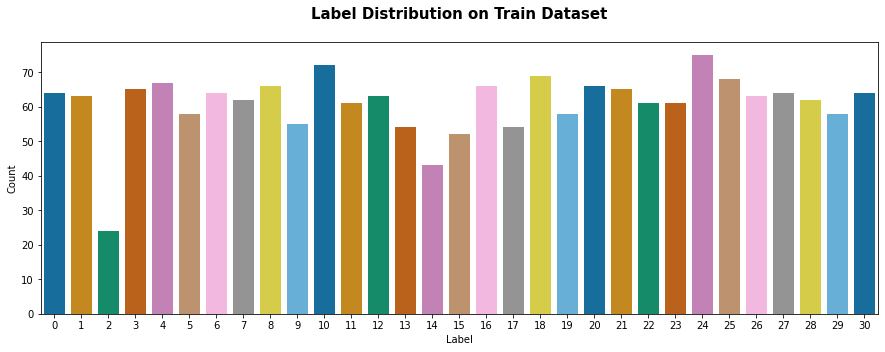

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(15,5))
sns.countplot(data=train_dataset, x='label', palette='colorblind')
plt.title('Label Distribution on Train Dataset\n', fontdict={
    'fontsize': 15, 'fontweight': 'bold'
})
plt.xlabel('Label', fontdict={
    'fontsize': 10
})
plt.ylabel('Count', fontdict={
    'fontsize': 10
})
plt.show()

### 1.4: Create dataloader

In [ ]:
train_dataset = PreprocessDataLoader(train_dataset, 'OFFICE31/amazon/')
validation_dataset = PreprocessDataLoader(validation_dataset, 'OFFICE31/amazon/')
test_dataset = PreprocessDataLoader(test_dataset, 'OFFICE31/amazon/')

In [ ]:
from torch.utils.data import DataLoader


BATCH_SIZE = 64

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## Step 2: Model Training
___

### 2.1: Train wrapper

In [ ]:
import os


GDRIVE_DIR = '/content/drive/MyDrive/IF5171-DL-2/'
DATA_DIR = 'data'
MODEL_DIR = 'models'
LOG_DIR = 'logs'

EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

In [ ]:
import os
import time as timer
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def train_wrapper(model, trainer, 
                  train_dataloader, validation_dataloader, test_dataloader, 
                  epochs=10, saved_model_name='model.pth', log_name='log.txt'):
  model_path = os.path.join(GDRIVE_DIR, MODEL_DIR)
  log_path = os.path.join(GDRIVE_DIR, LOG_DIR)

  if not os.path.exists(model_path):
    os.makedirs(model_path)
  if not os.path.exists(log_path):
    os.makedirs(log_path)

  model_path = os.path.join(model_path, saved_model_name)
  log_path = os.path.join(log_path, log_name)

  train_history = []

  with open(log_path, 'a') as fh:
    fh.write('epoch\ttrain_acc\ttest_acc\n')
    for epoch in range(epochs):
      print(f"Epoch {epoch+1} out of {epochs}\n ------------")
      start = timer.time()
      # Train model
      trainer.train(train_dataloader, print_log=False)  
      elapsed_time = timer.time() - start
      print(f"Training time: {elapsed_time:>.2f} seconds")
      # Evaluate model: get training accuracy 
      training_accuracy = trainer.test(validation_dataloader, print_log=False)
      # Evaluate model: get testing accuracy
      testing_accuracy = trainer.test(test_dataloader, print_log=False)
      # Append history
      train_history.append([epoch, training_accuracy, testing_accuracy])
      # Write log
      fh.write(f'{epoch}\t{training_accuracy}\t{testing_accuracy}\n')
      # Save model
      torch.save(model.state_dict(), model_path)
      print(f"Model {model_path} stored!\n")
  
  train_history = pd.DataFrame(train_history, columns=['epoch', 'train_acc', 'test_acc'])

  # Plot accurcy
  plt.figure()
  train_history.drop(columns=['epoch']).plot.line()
  plt.title(f'{saved_model_name} Accuracy History over Epochs\n', fontdict={
      'fontsize': 15, 'fontweight': 'bold'
  })
  plt.xlabel('Epoch', fontdict={
      'fontsize': 10
  })
  plt.ylabel('Accuracy', fontdict={
      'fontsize': 10
  })
  plt.show()

  print("Done!")

### 2.2: Fine tuning ResNet18

#### A: Using SGD optimizer

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 21:21:07 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0    43W / 400W |      3MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 30/30 [00:15<00:00,  1.88it/s]


...

100%|██████████| 30/30 [00:04<00:00,  6.52it/s]


Training time: 4.61 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/fine-tuned-resnet18_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.51it/s]


Training time: 4.61 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/fine-tuned-resnet18_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

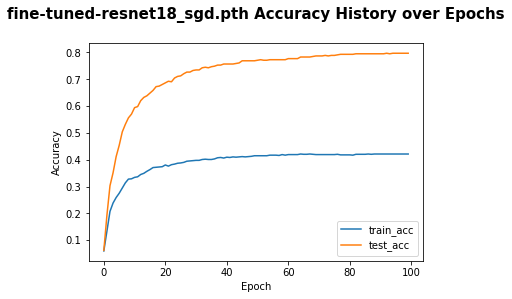

Done!


In [ ]:
model = fine_tuned_resnet18(d_class=len(label))
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=100, saved_model_name='fine-tuned-resnet18_sgd.pth', log_name='fine-tuned-resnet18_sgd.txt')

#### B: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 21:34:41 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   34C    P0    49W / 400W |   2026MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 30/30 [00:04<00:00,  6.25it/s]


Training time: 4.81 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/fine-tuned-resnet18_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.27it/s]


...

100%|██████████| 30/30 [00:04<00:00,  6.23it/s]


Training time: 4.82 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/fine-tuned-resnet18_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.29it/s]


Training time: 4.78 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/fine-tuned-resnet18_adam.pth stored!



<Figure size 432x288 with 0 Axes>

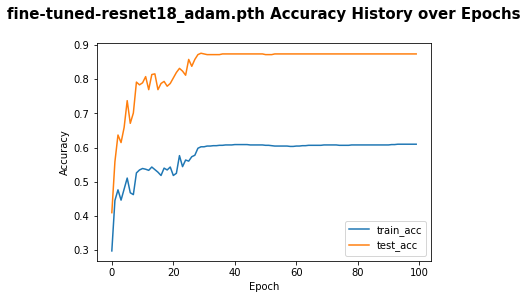

Done!


In [ ]:
model = fine_tuned_resnet18(d_class=len(label))
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=100, saved_model_name='fine-tuned-resnet18_adam.pth', log_name='fine-tuned-resnet18_adam.txt')

### 2.3: ResNet18 as feature extractor

#### A: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 21:48:17 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0    49W / 400W |   2094MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 30/30 [00:04<00:00,  6.86it/s]


Training time: 4.38 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_sgd.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.84it/s]


...

100%|██████████| 30/30 [00:04<00:00,  6.90it/s]


Training time: 4.36 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_sgd.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.84it/s]


Training time: 4.39 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

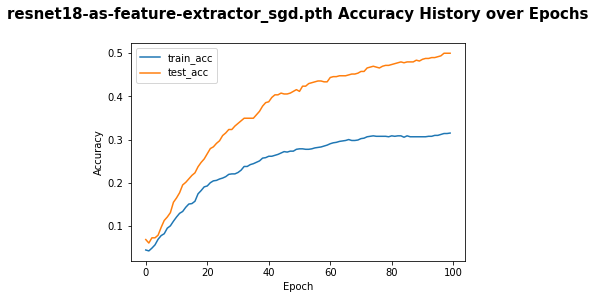

Done!


In [ ]:
model = resnet18_as_feature_extractor(d_class=len(label))
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=100, saved_model_name='resnet18-as-feature-extractor_sgd.pth', log_name='resnet18-as-feature-extractor_sgd.txt')

#### B: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Thu Oct  6 22:01:09 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM4-40GB      Off  | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P0    49W / 400W |   2094MiB / 40536MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 30/30 [00:04<00:00,  6.83it/s]


Training time: 4.40 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_adam.pth stored!

Epoch 2 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.87it/s]


...

100%|██████████| 30/30 [00:04<00:00,  6.85it/s]


Training time: 4.38 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_adam.pth stored!

Epoch 100 out of 100
 ------------


100%|██████████| 30/30 [00:04<00:00,  6.82it/s]


Training time: 4.40 seconds
Model /content/drive/MyDrive/IF5171-DL-2/models/resnet18-as-feature-extractor_adam.pth stored!



<Figure size 432x288 with 0 Axes>

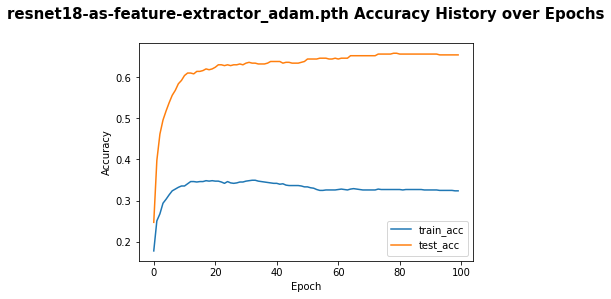

Done!


In [ ]:
model = resnet18_as_feature_extractor(d_class=len(label))
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=100, saved_model_name='resnet18-as-feature-extractor_adam.pth', log_name='resnet18-as-feature-extractor_adam.txt')